
--- MATRIZ NORMALIZADA ---
                 Preço (R$)  Qualidade (μm)  Volume (L)  Velocidade (mm/s)
Impressora                                                                
Raise3D Pro2         0.1568             0.5      0.5037                0.2
Creality K1 Max      0.8432             0.5      0.4963                0.8

--- TABELA DE PESOS GAUSSIANOS ---
                   Média  Desvio Padrão  Fator L (Gauss)  Peso Final (%)
Preço (R$)           0.5         0.3432           0.6865         53.0572
Qualidade (μm)       0.5         0.0000           0.0000          0.0000
Volume (L)           0.5         0.0037           0.0074          0.5683
Velocidade (mm/s)    0.5         0.3000           0.6000         46.3745

--- RANKING FINAL ---
Impressora
Creality K1 Max    0.8212
Raise3D Pro2       0.1788
dtype: float64


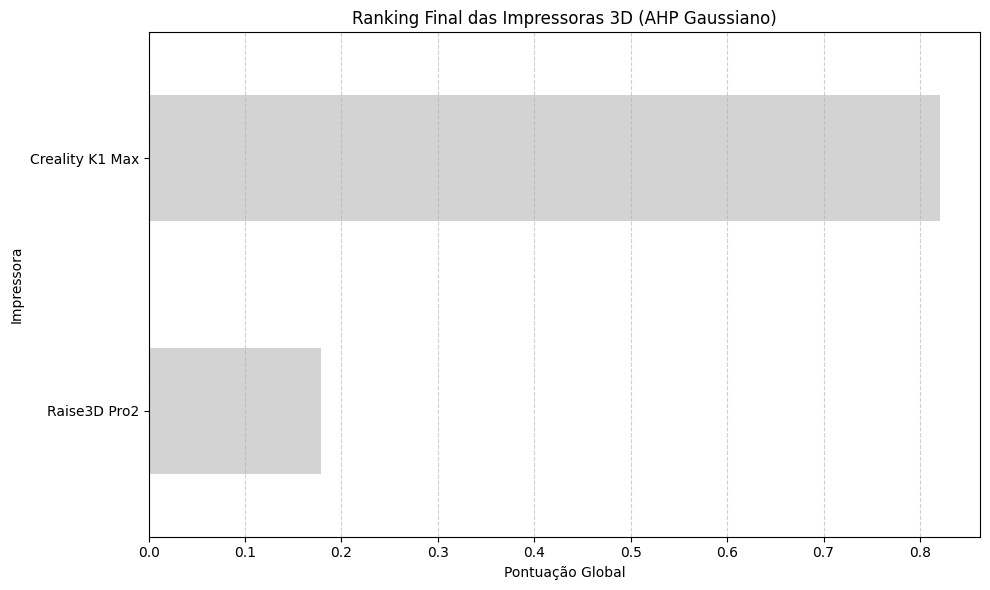

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 1. DADOS BRUTOS DO EXCEL
try:
    df = pd.read_excel('CEN4.xlsx', index_col=0)
except FileNotFoundError:
    print("Erro: O arquivo 'CEN4.xlsx' não foi encontrado. Verifique o nome e a pasta.")
    exit()

# 2. NORMALIZAÇÃO LINEAR (Soma)
df_norm = df.copy().astype(float)

# Inverter critérios de Custo (Preço e Qualidade)
df_norm['Preço (R$)'] = 1 / df_norm['Preço (R$)']
df_norm['Qualidade (μm)'] = 1 / df_norm['Qualidade (μm)']

# Dividir cada valor pela soma da sua respectiva coluna
df_norm = df_norm / df_norm.sum()

# 3. CÁLCULO DOS PESOS GAUSSIANOS
medias = df_norm.mean()
desvios = df_norm.std(ddof=0) 
fator_gauss = desvios / medias
pesos = fator_gauss / fator_gauss.sum()

# 4. RANKING FINAL
ranking = df_norm.dot(pesos).sort_values(ascending=False)

# --- EXIBIÇÃO DE TABELAS NO TERMINAL ---
print("\n--- MATRIZ NORMALIZADA ---")
print(df_norm.round(4))

print("\n--- TABELA DE PESOS GAUSSIANOS ---")
df_pesos = pd.DataFrame({
    'Média': medias,
    'Desvio Padrão': desvios,
    'Fator L (Gauss)': fator_gauss,
    'Peso Final (%)': pesos * 100
})
print(df_pesos.round(4))

print("\n--- RANKING FINAL ---")
print(ranking.round(4))

# --- GRÁFICO 1: RANKING DE BARRAS ---
plt.figure(figsize=(10, 6))
colors = []
for nome in ranking.index:
    if 'Anycubic' in nome:
        colors.append('royalblue')
    else:
        colors.append('lightgrey')

ranking_plot = ranking.sort_values(ascending=True)
colors_plot = []
for nome in ranking_plot.index:
    if 'Anycubic' in nome:
        colors_plot.append('royalblue')
    else:
        colors_plot.append('lightgrey')

ranking_plot.plot(kind='barh', color=colors_plot)

plt.title('Ranking Final das Impressoras 3D (AHP Gaussiano)')
plt.xlabel('Pontuação Global')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('ranking_CEN4.png')


# Exportar imagem para excel
ranking.to_excel("resultado_CEN4.xlsx")

#Exportar tabelas para excel
with pd.ExcelWriter('Resultados_CEN4.xlsx') as writer:
    df_norm.to_excel(writer, sheet_name='Matriz Normalizada')
    df_pesos.to_excel(writer, sheet_name='Tabela de Pesos Gaussianos')